# BLG454E Learning From Data Homework 1

All instructions about the homework are given in HW1_Fall2526.ipynb file. Do create any additional code or report files. Do not import additional libraries; only use the built-in functions and the libraries already imported in the notebook. Provide detailed comments and explanations for your results. If you have any questions, send an email to erzurumluoglu18@itu.edu.tr.

Name Surname: Furkan Kural

Student No: 150210056

---

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Part 1: Simple Linear Regression  (30 points)

### Background

Remember from the course material: In Linear Regression, we aim to find the line that fits the given data as well as possible. The line formula is:

### <center> $ \hat{y} = f(x) = \beta_0 + \beta_1 x $ <center> 

And using linear regression, the goal is to find the $\beta_0$ and $\beta_1$ such that the the Mean Squared Error (MSE) is minimized:
    
### <center> $ MSE \Rightarrow \mathcal{L} = \dfrac{1}{N} \sum_{i=1}^{N} (y_i - f(x_i ))^2 $ <center> 
    
As the MSE error gets smaller, the line starts to represent the data better and better.
    
Consider $\beta = (\beta_0 + \beta_1)$. In order to find the $\beta$ that minimizes the MSE loss, we use **Gradient Descent**. Iteratively $\beta$ is updated in the opposite direction of the gradient, while the size of the update is controlled with the learning rate $\eta$:
    
### <center> $ \beta \leftarrow \beta-\eta \frac{d \mathcal{L}}{d \beta} $ <center> 

### Your Task

In this part, you are going to code up Simple Linear Regression, and find the line that fits the data best. To do so, you'll need to complete the following:

- Code up the gradient descent, and print the loss value at every time step. You can use the number of steps as the stopping criteria (e.g. stopping gradient descent after 10 steps). 
- At the end of the algorithm, plot the found line with the data .
    
Given learning rate and number of iterations as default values in the code should work, but you are free to change them to make your algorithm faster if you'd like. You are not allowed to use any libraries other than the imported ones at the beginning. You can initialize the $\beta$ randomly.

In [13]:
from sklearn.datasets import make_regression

def load_data():
    x, y = make_regression(n_samples=100, n_features=1, noise=10.0, bias=3.0, random_state=42)
    return x[:, 0], y

def gradient_descent(x, y, learning_rate = 0.01, max_its = 500):
    # TO DO: Initialize the beta values
    # Beta starting randomly
    beta0 = np.random.randn()
    beta1 = np.random.randn()

    N = len(y)

    # start gradient descent loop
    for k in range(0, max_its):
        # TO DO: calculate derivative (grad)
        # 1. prediction y
        y_pred = beta0 + beta1 * x
        
        # 2. Erroe (Residuals)
        residuals = y - y_pred
        
        # 3. Calculating Derivatives (Gradients)
        d_beta0 = -(2/N) * np.sum(residuals)
        d_beta1 = -(2/N) * np.sum(residuals * x)
        
        # TO DO: take gradient descent step
        # 4. updating
        beta0 = beta0 - learning_rate * d_beta0
        beta1 = beta1 - learning_rate * d_beta1
        
        # TO DO: calculate and print the loss value
        # We print the error (MSE) every 50 steps
        if k % 50 == 0:
            loss = np.mean(residuals**2)
            print(f"Step {k}: MSE Loss = {loss:.4f}")

    return beta0, beta1

Step 0: MSE Loss = 1586.7812
Step 50: MSE Loss = 373.5964
Step 100: MSE Loss = 137.3514
Step 150: MSE Loss = 90.1306
Step 200: MSE Loss = 80.5360
Step 250: MSE Loss = 78.5670
Step 300: MSE Loss = 78.1605
Step 350: MSE Loss = 78.0763
Step 400: MSE Loss = 78.0588
Step 450: MSE Loss = 78.0552


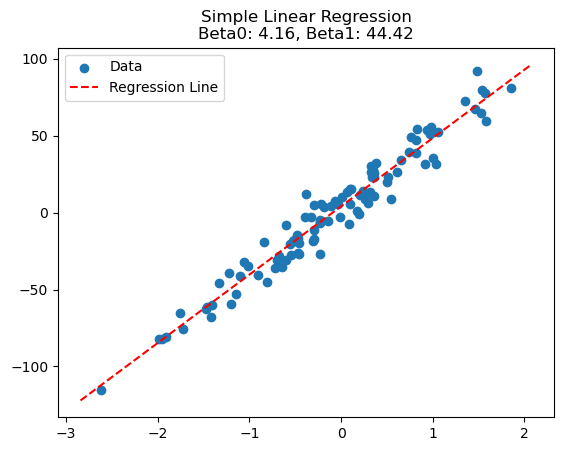

In [14]:
x, y = load_data()
# We call the gradient descent function
beta0, beta1 = gradient_descent(x, y, learning_rate=0.01, max_its=500)

# Plotting data
plt.scatter(x, y, label='Data')
axes = plt.gca()
x_vals = np.array(axes.get_xlim())
y_vals = beta0 + beta1 * x_vals

# Drawing the line we found
plt.plot(x_vals, y_vals, '--', color='red', label='Regression Line')
plt.legend()
plt.title(f"Simple Linear Regression\nBeta0: {beta0:.2f}, Beta1: {beta1:.2f}")
plt.show()

# Part 2: Multi Linear Regression on California House Pricing Dataset using 5-fold Cross Validation (20 points)

In this part, you are going to train a Multi Linear Regression Model on a real dataset! The dataset we are going to use is **California House Pricing Dataset**. The target is to predict the median house value in California, given the 8 features ( You can examine the name of the features when you run the load_data function given below ). In this part, you will also use Cross-Validation with 5 folds, in addition to everything you implemented in Part 1. You will also alter your code so that it works with multiple attribute. In this case, you will have 8 features and you can code up assuming you will always have 8 features. At the end, you will report your results. 

In summary, you will need to do the following:

- Code up gradient descent with Cross Validation for Multi Linear Regression
- Find the best working learning rate and number of iterations setup.
- Report the MSE loss periodically during training in folds (For example, if you are training for 1000 steps, you can print MSE loss for each 100 steps. If you are training for 100000 steps ( which you can, if you'd like ), you can print MSE loss for each 10000 steps. In total, if you print the loss 10 times periodically for each fold, it's fine ).
- Save the final MSE results on the testing set on each fold in an array. Print the average testing MSE losses at the end of the algorithm. Additionally, print the variance of the testing MSE losses. 

In this part, we are giving you only the load_data function, so you are flying solo for Linear Regression Part! It is up to you to find the working learning rate and number of iterations setup. In addition to the libraries imported for Part 1, you are allowed to use sklearn for fetching dataset (which is already done for you), and the KFold class for the cross-validation. Other than that, you are not allowed to use sklearn or any other additional libraries.



In [15]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import KFold

def load_data():
    data = fetch_california_housing()
    
    print("Features of dataset: ", data.get("feature_names"))
    print("Shape of the X: ", data.data.shape)
    print("Shape of the Y: ", data.target.shape)
    return data.data, data.target

def multiple_gradient_descent_KFold(x, y, learning_rate=0.01, max_its=1000, k_folds=5):
    # 1. Manual Data Normalization (Standardization)
    # Formula: (x - mean) / std
    mean = np.mean(x, axis=0)
    std = np.std(x, axis=0)
    x_normalized = (x - mean) / std
    
    # 2. Add a column of 1s to the beginning of X for the bias term (beta0)
    ones = np.ones((x_normalized.shape[0], 1))
    X_b = np.hstack([ones, x_normalized])
    
    # Start K-Fold Cross Validation 
    kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)
    
    test_mses = [] # To store the result of each fold
    fold = 1

    for train_index, test_index in kf.split(X_b):
        # Separate Training and Test sets
        X_train, X_test = X_b[train_index], X_b[test_index]
        y_train, y_test = y[train_index], y[test_index]
        
        
        beta = np.random.randn(X_train.shape[1])
        N_train = len(y_train)
        
        # Gradient Descent loop
        for k in range(max_its):
            # Estimate by matrix multiplication: X * beta
            y_pred = X_train.dot(beta)
            
            # Error calculation
            error = y_train - y_pred
            
            # Gradient calculation (Vector derivative)
            gradients = -(2/N_train) * X_train.T.dot(error)
            
            # Update
            beta = beta - learning_rate * gradients
            
            
        
        # When the fold is finished, measure the performance on the test set.
        y_test_pred = X_test.dot(beta)
        test_mse = np.mean((y_test - y_test_pred)**2)
        test_mses.append(test_mse)
        print(f"Fold {fold} Test MSE: {test_mse:.4f}")
        
        fold += 1

    # Reporting results
    print("\n--- Final Results ---")
    print(f"Average Test MSE: {np.mean(test_mses):.4f}")
    print(f"Variance of Test MSE: {np.var(test_mses):.4f}")

In [16]:
x, y = load_data()

multiple_gradient_descent_KFold(x, y, learning_rate=0.1, max_its=2000, k_folds=5)

Features of dataset:  ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Shape of the X:  (20640, 8)
Shape of the Y:  (20640,)
Fold 1 Test MSE: 0.5559
Fold 2 Test MSE: 0.5277
Fold 3 Test MSE: 0.5093
Fold 4 Test MSE: 0.5049
Fold 5 Test MSE: 0.5552

--- Final Results ---
Average Test MSE: 0.5306
Variance of Test MSE: 0.0005


# Part 3: Gaussian Naive Bayes Classifier (30 points)

### Background
Gaussian Naive Bayes classifiers combine class-conditional likelihoods with Bayes’ rule. In Gaussian Naive Bayes (GNB), each feature is assumed conditionally independent given the class and follows a Gaussian distribution:

### <center> $ \displaystyle p(x~|~C_k) = \prod^{d}_{j=1} \mathcal{N} (x_j~ |~ \mu_{kj}, \sigma^2_{kj}) $ <center> 

Working in the log domain is numerically stable. The decision rule compares class scores

### <center> $ \displaystyle \log P(C_k) + \sum^{d}_{j=1} \biggr[ - \dfrac{1}{2} \log (2 \pi \sigma^2_{kj}) - \dfrac{(x_j - \mu_{kj})^2}{2\sigma^2_{kj}} \biggr] $ <center>

and predicts the class with the largest score:

### <center> $ \hat{y} = \arg\max_k [ \log P(C_k) + \log p(x~|~C_k) ] $ <center> 

Because the covariance is assumed to be diagonal (independence), GNB is fast and robust with limited data.

### Your Task
In this part, you will implement Gaussian Naive Bayes from scratch and evaluate it with a single train/test split.
- First, you will calculate the class statistics:
    - Class priors 
    - Class-conditional means 
    - Class-conditional variances
    - Add a small $\epsilon$ to each variance for numerical stability.
- Then, to predict, compute log-likelihoods + log-priors and choose the class.

In [17]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

def load_data():
    data = load_iris()
    X, y = data.data, data.target
    print("Classes:", np.unique(y))
    print("X shape:", X.shape, "y shape:", y.shape)
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    return X_train, X_test, y_train, y_test

def compute_class_stats(X, y):
    stats = {}
    classes = np.unique(y)
    
    for c in classes:
       
        X_c = X[y == c]
        
        stats[c] = {
            'mean': np.mean(X_c, axis=0),
            # We add a very small number (epsilon) to the variance so that there is no division by 0 error.
            'var': np.var(X_c, axis=0) + 1e-9, 
            'prior': len(X_c) / len(X)
        }
    return stats

def predict_gnb(X, stats):
    predictions = []
    
    for x in X:
        class_scores = {}
        
        for c, stat in stats.items():
            mean = stat['mean']
            var = stat['var']
            prior = stat['prior']
            
            # Log Prior
            log_prior = np.log(prior)
            
            # Log Likelihood (Gaussian Formülü)
            # -0.5 * log(2*pi*var) - (x-mean)^2 / (2*var)
            log_likelihood = np.sum(-0.5 * np.log(2 * np.pi * var) - ((x - mean)**2 / (2 * var)))
            
           
            class_scores[c] = log_prior + log_likelihood
        
        
        best_class = max(class_scores, key=class_scores.get)
        predictions.append(best_class)
        
    return np.array(predictions)


def print_accuracy(y_true, y_pred):
    accuracy = np.mean(y_true == y_pred)
    print(f"Accuracy: {accuracy:.4f}")

def plot_confusion_matrix(y_true, y_pred):
    print("\nConfusion Matrix:")
    
    print(pd.crosstab(y_true, y_pred, rownames=['Actual'], colnames=['Predicted']))

In [18]:
X_train, X_test, y_train, y_test = load_data()
stats = compute_class_stats(X_train, y_train)
y_pred = predict_gnb(X_test, stats)
print_accuracy(y_test, y_pred)
plot_confusion_matrix(y_test, y_pred)

Classes: [0 1 2]
X shape: (150, 4) y shape: (150,)
Accuracy: 0.9667

Confusion Matrix:
Predicted   0  1   2
Actual              
0          10  0   0
1           0  9   1
2           0  0  10


# Part 4: Probability Questions (20 Points)

In this part, you are given 2 probability questions that you will solve by hand (You do not code anything). We ask you to insert an image of your handwritten solution on paper. If you drag & drop or paste an image into a Markdown cell, it’s stored as an attachment. This way, you do not have to keep the image in local, it will be directly embedded in the notebook file. Try to keep your answers as illustrative as possible.

### Question 1

Luna and Pasha are two cats with different wet-food schedules. On any given day, Luna gets wet food with probability 0.45, and Pasha gets wet food with probability 0.35. (Assume these events are independent.)

If both cats get wet food on the same day, they are extra excited, and the probability that they fight is 0.25. Otherwise, when at least one of them does not get wet food, the probability that they fight is 0.06.

For a randomly selected day:
- What is the probability that Luna gets wet food, Pasha does not, and the cats do not fight?
- What is the overall probability that the cats fight?

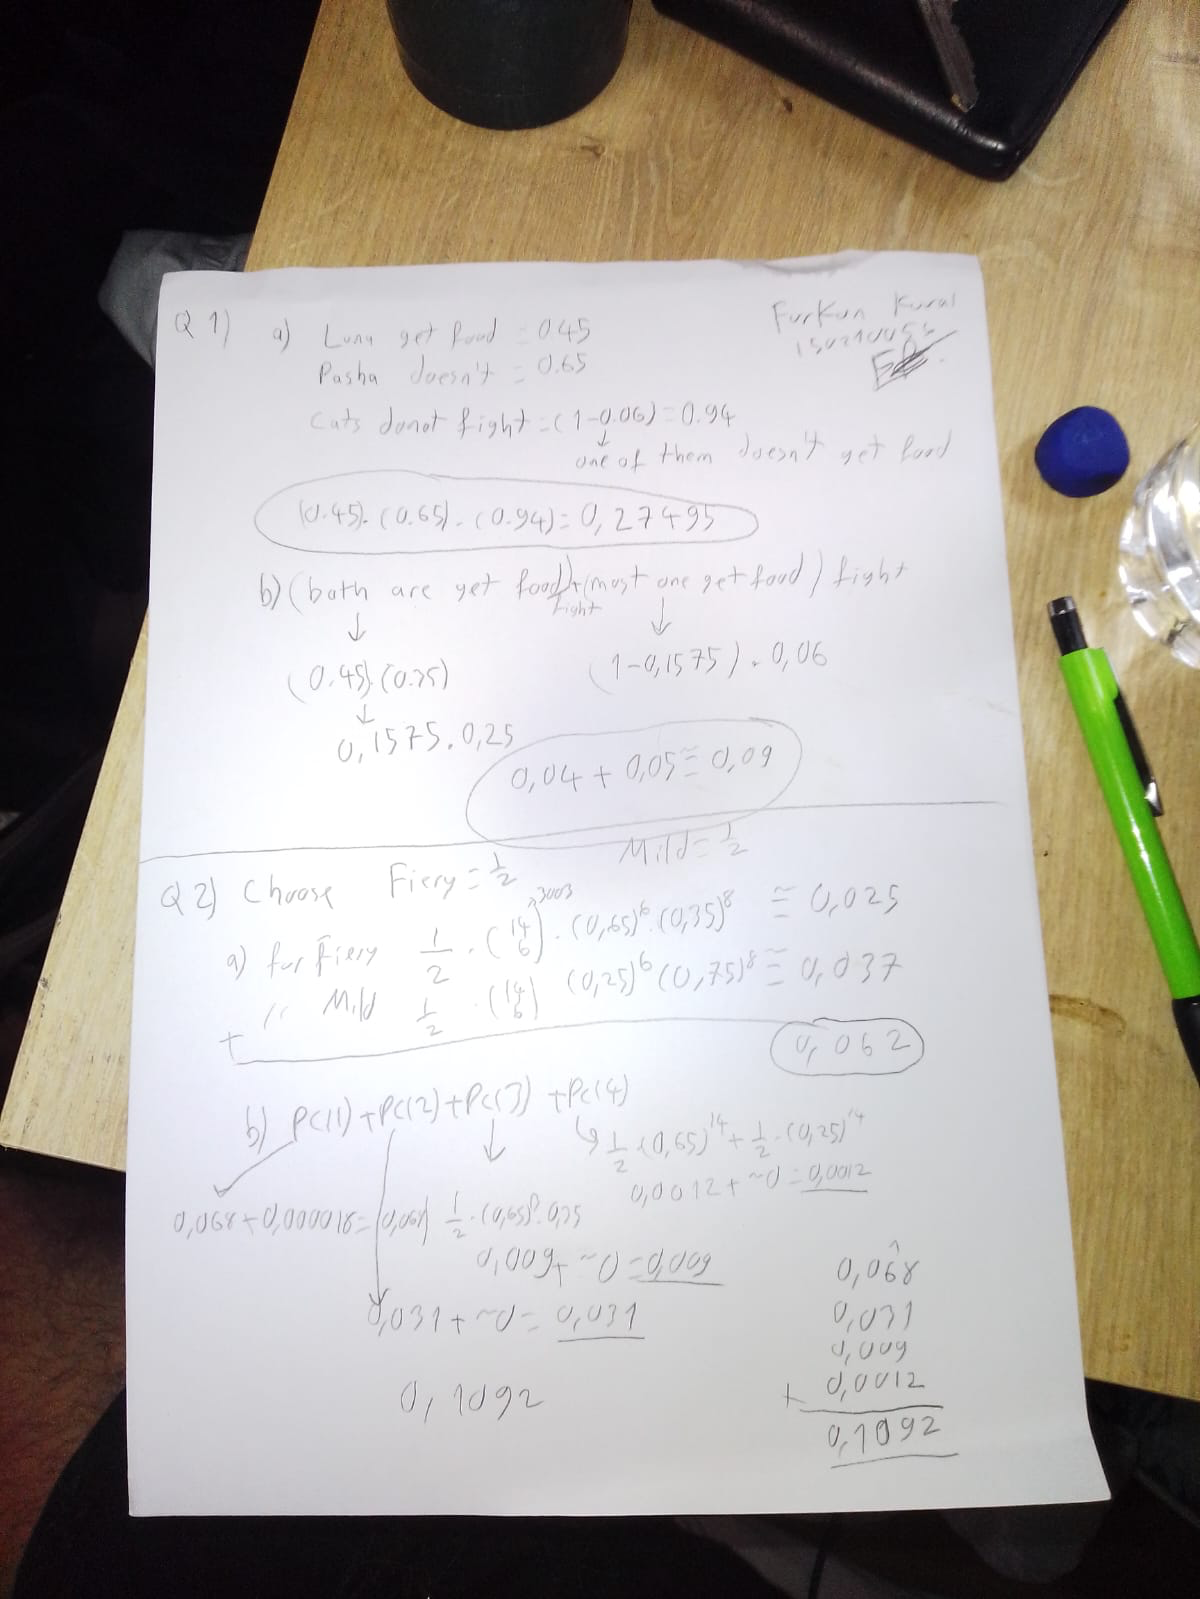

### Question 2

Two identical-looking bowls of chips sit on the table. One bowl is a Fiery Mix, where each chip is very spicy with probability 0.65. The other is a Mild Mix where each chip is very spicy with probability 0.25. You don’t know which bowl is which. You picked one bowl at random and then ate 14 chips.

- What is the probability of getting exactly 6 very spicy chips?
- What is the probability of getting at least 11 very spicy chips?


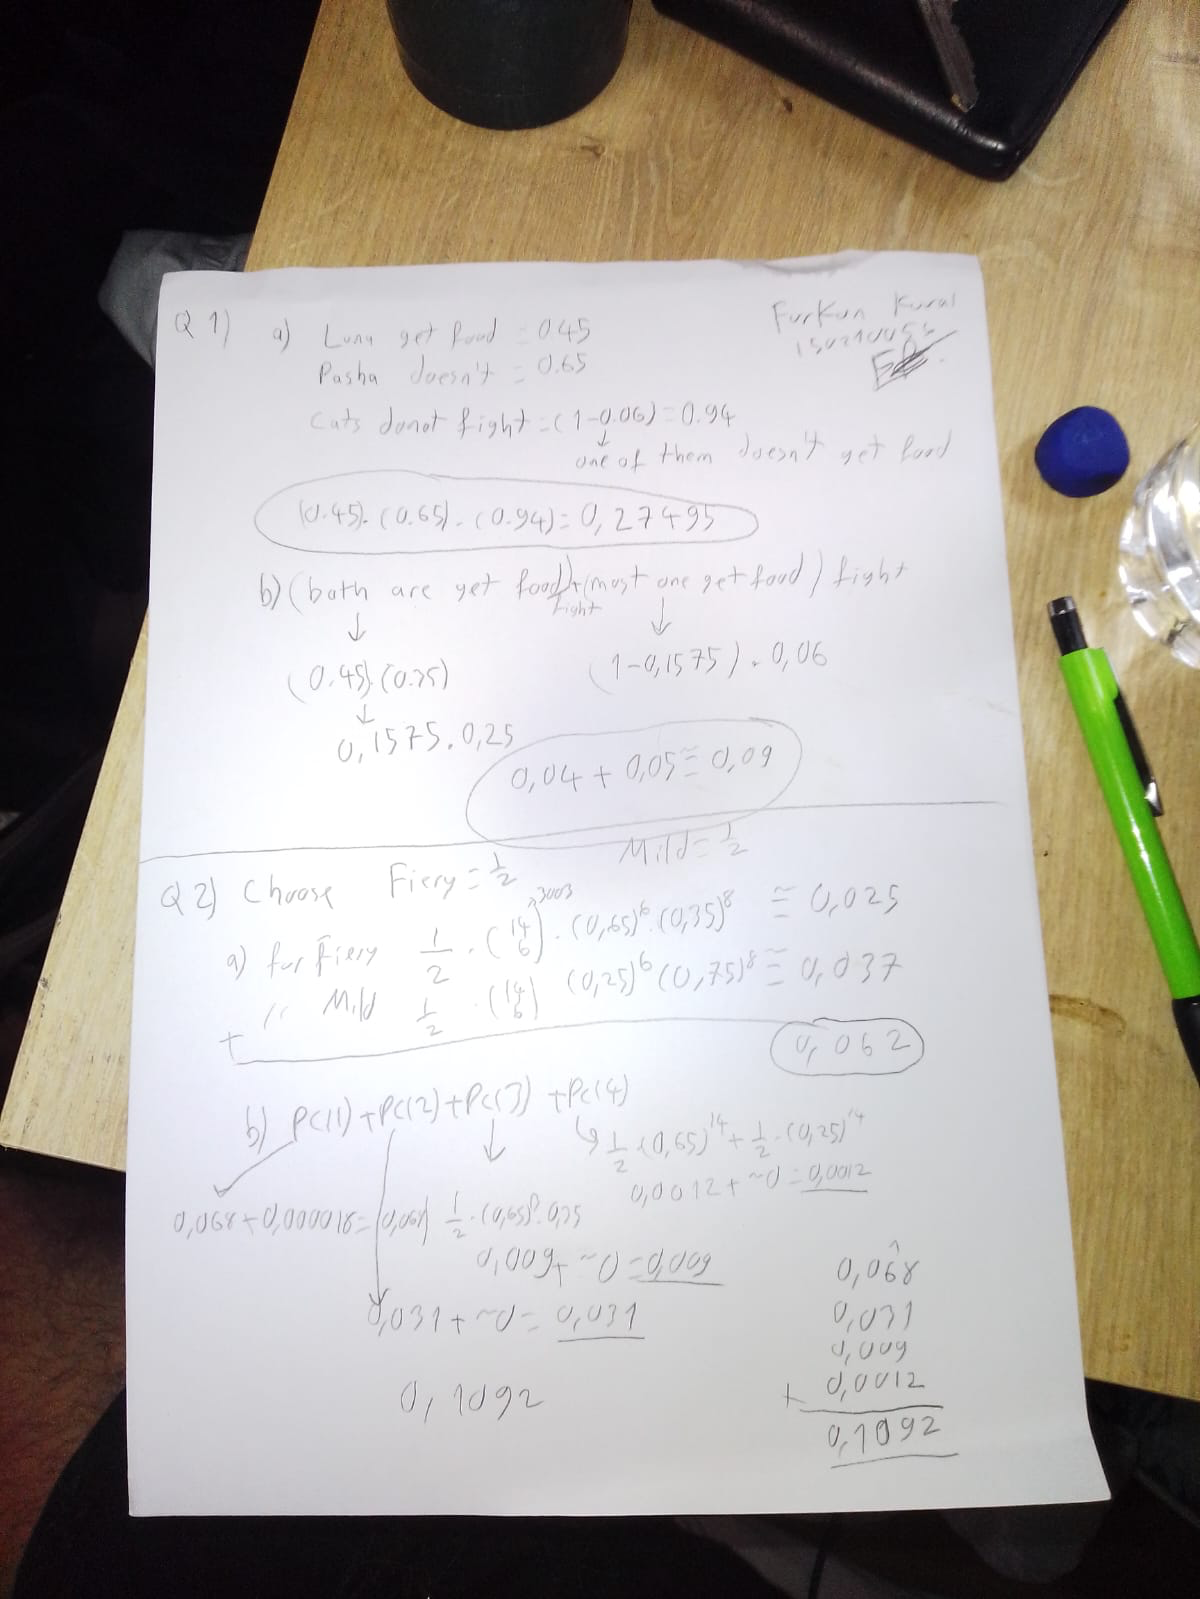